#What Makes a Restaurant Successful in New Orleans
##Nahema Dumonteil & Hannah Bajaj
## Website link: https://nahemad.github.io/RestaurantProject-3.html

**Project Goal**
The goal of this project is to investigate what factors contribute to restaurant success in New Orleans. We define restaurant success using measurable indicators such as average customer rating and the number of reviews on Yelp, which serve as proxies for customer satisfaction and popularity.

**Description of Dataset**:
Our primary dataset comes from the Yelp business and review data. The restaurant dataset includes attributes such as restaurant name, location, star ratings, review counts, cuisine type and available amenities such as WiFi. This dataset will help us answer our project question because by examining the relationship between ratings, number of reviews, and other restaurant attributes, we can identify trends that help explain differences in how customers examine the restaurants. We will focus specifically on restaurants located in New Orleans. In addition to including data on the price ranges of restaurants, some other data that we plan on using is neighborhood data from Nola Gov to see different socioeconomic factors. Some questions we hope to answer are the following:
 1. What are the average and medians of the ratings? Are people enjoying restaurants in New Orelans?
  2. Review count, how much are people reviewing the restaurants in the first place?
  3. Is there a correlation between ratings and reviews?
  4. Distribution of restaurants by cuisine. Are certain cuisine types more popular or successful in New Orleans?
  Question to answer with additional data:
   1. Is there a correlation between price and ratings? Do higher-priced restaurants tend to receive higher ratings?
   2. Do restaurants located in higher-income neighborhoods receive more reviews or higher ratings?
   3. Does location within the city influence restaurant popularity?

  In this milestone we hope to answer the question: How does restaurant characteristics such as cuisine type and customer engagement (reviews) relate to restaurants success in New Orleans as measured by Yelp ratings?

  **Collaboration Plan:**
We will both collaborate on all stages of the project, including data collection, cleaning, analysis, and visualization.Most of the coding and analysis will be completed together during scheduled meetings where we will review progress, write code, and interpret results as a team. Wroking together at the same time will ensure we divide the work fairly.

Link to dataset website: https://www.kaggle.com/datasets/ranjulajayarathna/cleaned-yelp-dataset-restaurants-and-reviews



#Downloading and Reading the Data

In [13]:
#We wont be using this data for this milestone but we believe it could be useful in the
#future so we will keep it for documentation purposes.

!pip install gdown

import gdown
#get data set form google drive and download it
file_id = "16seDLM9CA_eZ3yu3sYsl0W0Jh-Y4vwTZ"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url)



Downloading...
From (original): https://drive.google.com/uc?id=16seDLM9CA_eZ3yu3sYsl0W0Jh-Y4vwTZ
From (redirected): https://drive.google.com/uc?id=16seDLM9CA_eZ3yu3sYsl0W0Jh-Y4vwTZ&confirm=t&uuid=e579fb26-9b57-4fe9-b8d9-a235846b723d
To: /content/yelp_academic_dataset_business.json
100%|██████████| 119M/119M [00:01<00:00, 83.4MB/s]


'yelp_academic_dataset_business.json'

In [3]:

# This is another data set that we found that is cleaned and we will use it in this milestone.
# This data set is from Kaggle, here is the link: https://www.kaggle.com/datasets/ranjulajayarathna/cleaned-yelp-dataset-restaurants-and-reviews
import kagglehub
path = kagglehub.dataset_download("ranjulajayarathna/cleaned-yelp-dataset-restaurants-and-reviews")

import os

print(os.listdir(path))

import pandas as pd

restaurants = pd.read_csv(path + "/cleaned_yelp_restaurants.csv")
reviews = pd.read_csv(path + "/sampled_yelp_reviews.csv")

restaurants.head()

100%|██████████| 3.03M/3.03M [00:00<00:00, 122MB/s]

Extracting files...
['cleaned_yelp_restaurants.csv', 'sampled_yelp_reviews.csv']


,business_id,name,city,state,stars,review_count,categories,WiFi_Status
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",u'free'
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",u'no'
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",u'no'
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",No Info
4,il_Ro8jwPlHresjw9EGmBg,Denny's,Indianapolis,IN,2.5,28,"American (Traditional), Restaurants, Diners, B...",u'no'


# PART 1: TIDY DATA AND FILTER NEW ORLEANS RESTAURANTS

In [14]:
#Check Data Type
restaurants.info()

#Check for NaN values
restaurants.isna().sum()

#Wifi Status has NaN's so we can replace with Unknown
restaurants["WiFi_Status"] = restaurants["WiFi_Status"].fillna("Unknown")

#Filter
nolaRestaurants = restaurants[restaurants['city'] == 'New Orleans']

#Confirm
nolaRestaurants.head()

#No. of NOLA Restaurants
nolaRestaurants.shape



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34987 entries, 0 to 34986
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   34987 non-null  object 
 1   name          34987 non-null  object 
 2   city          34987 non-null  object 
 3   state         34987 non-null  object 
 4   stars         34987 non-null  float64
 5   review_count  34987 non-null  int64  
 6   categories    34987 non-null  object 
 7   WiFi_Status   34987 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.1+ MB


(1391, 8)

#PART 2: STATISTICS

### Average Yelp Rating (Quality)

We are investigating the overall quality of the restaurants in New Orleans. The average Yelp rating of the New Orleans restaurants is approximately 3.76 stars, showing decent customer satisfaction ratings.

In [15]:
round(float(nolaRestaurants['stars'].mean()),2)

3.76

### Average Review Count (Popularity)

We are measuring the New Orleans restaurant popularity or visibility. Restaurants receive an average of about 278 reviews.

Some of the more established resaurants are receiving significantly more reviews.

In [16]:
round(float(nolaRestaurants['review_count'].mean()),2)

278.21


### Correlation between the Ratings and the Volume of Reviews

Looking at whether the New Orleans restaurants that are considered "better" attract more attention. Based on the correlation analysis between the Yelp ratings and the volume of reviews, we are able to determine whether the higher-rated restaurants tend to have a higher customer engagement.

Based on the data, restaurants with higher ratings do tend to have SLIGHTLY more reviews but the overall relationship is very weak (0.1147 = very weak positive correlation). This means that higher-rated restaurants are not a strong predictor of whether a restaurant is popular.



In [17]:
nolaRestaurants[['stars','review_count']].corr()

,stars,review_count
stars,1.000000,0.114694
review_count,0.114694,1.000000


### MOST POPULAR RESTAURANT

Restaurants with the highest review counts are generally considered more popular within New Orleans.

Based on the analysis, Acme Oyster House and Oceana Grill are considered to be some of the most reviewed establishment with over 7000 reviews. Most of the restaurants that take the top ten have ratings between 4.0 and 4.5 stars which could suggest that the popular restaurants tend to maintain high ratings.

However, some very popular restaurants don't always have the highest ratings. Mother's restaurant has a 3.5 star ratings with over 5000 reviews indicating the correlation to be weaker but present.

In [18]:
nolaRestaurants.sort_values(by='review_count', ascending=False)[['name','stars','review_count']].head(10)

,name,stars,review_count
26439,Acme Oyster House,4.0,7568
26163,Oceana Grill,4.0,7400
34209,Ruby Slipper - New Orleans,4.5,5193
23267,Mother's Restaurant,3.5,5185
7267,Royal House,4.0,5070
7346,Commander's Palace,4.5,4876
1030,Luke,4.0,4554
22644,Cochon,4.0,4421
14949,Felix's Restaurant & Oyster Bar,4.0,3966
9850,Gumbo Shop,4.0,3902


### MOST COMMON CUISINES IN NEW ORLEANS

Analyzing the restaurant categories to determine which cuisine style is the most prevalent in New Orleans.

Chinese and Pizza Cuisines take the top rankings as they are more commonly found!

In [19]:
nolaRestaurants['categories'].value_counts().head(10)

,count
categories,
"Restaurants, Chinese",16
"Restaurants, Pizza",9
"Restaurants, Cajun/Creole",8
"Cajun/Creole, Restaurants",7
"Seafood, Restaurants",7
"Restaurants, Seafood",7
"American (New), Restaurants",6
"Restaurants, Cajun/Creole, Seafood",6
"Restaurants, Mexican",6


SUMMARY: These statistics show a brief overview of the dining lanscape in New Orleans, indicating that the more popular restaurants do maintain a relatively strong rating however it is not based on ratings alone. There are additional factors such as types of cuisine and location that also relate to restaurant success.

Therefore, POPULARITY AND QUALITY ARE NOT THE SAME THING.

###MOST POPULAR RESTAURANT'S CUISINE TYPE

In [21]:
nolaRestaurants.sort_values(by='review_count', ascending=False)[['name','categories','stars','review_count']].head(10)


,name,categories,stars,review_count
26439,Acme Oyster House,"Live/Raw Food, Seafood, Restaurants, Cajun/Creole",4.0,7568
26163,Oceana Grill,"Restaurants, Seafood, Cajun/Creole, Breakfast ...",4.0,7400
34209,Ruby Slipper - New Orleans,"Restaurants, American (Traditional), American ...",4.5,5193
23267,Mother's Restaurant,"Cajun/Creole, Restaurants, Event Planning & Se...",3.5,5185
7267,Royal House,"American (New), Restaurants, Sandwiches, Seafo...",4.0,5070
7346,Commander's Palace,"French, Restaurants, Cocktail Bars, Nightlife,...",4.5,4876
1030,Luke,"German, Restaurants, Seafood, Cocktail Bars, F...",4.0,4554
22644,Cochon,"Cajun/Creole, Seafood, Restaurants",4.0,4421
14949,Felix's Restaurant & Oyster Bar,"Restaurants, Sandwiches, Seafood, Cajun/Creole",4.0,3966
9850,Gumbo Shop,"Cajun/Creole, Seafood, Restaurants",4.0,3902


From inspection of the top 10 restaurants by review count, many of the restaurants fall under seafood-related categories. This suggests that seafood restaurants appear frequently among the most reviewed establishments in the dataset. This observation may indicate that seafood restaurants are popular in this region, although additional analysis would be needed to determine whether seafood restaurants tend to be more successful overall.

# PART 3: GRAPH

The graph below represents the distribution of the Yelp Ratings that show majority of New Orleans restaurants fall between 3.5 and 4.5 stars, showing a general positive customer satisfaction with cuisine in the city.

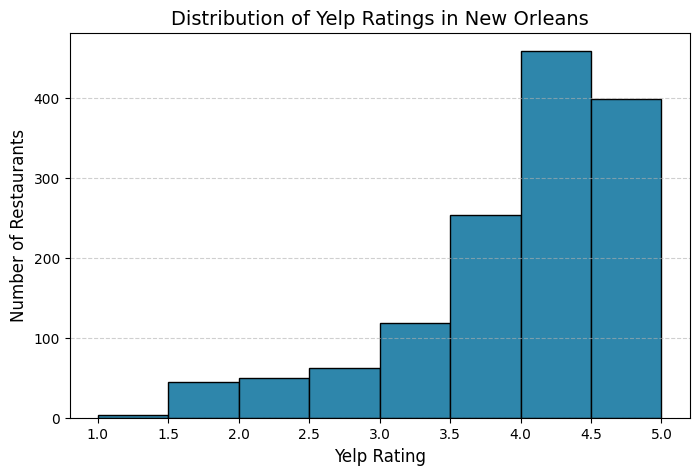

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(nolaRestaurants['stars'],
         bins=[1,1.5,2,2.5,3,3.5,4,4.5,5],
         color="#2E86AB",
         edgecolor="black")

plt.title("Distribution of Yelp Ratings in New Orleans", fontsize=14)
plt.xlabel("Yelp Rating", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Another interesting visualization could be a bar graph showing the relationship between review counts and cuisine type.

<Axes: title={'center': 'Top Categories in Top 10 Restaurants'}, xlabel='categories'>

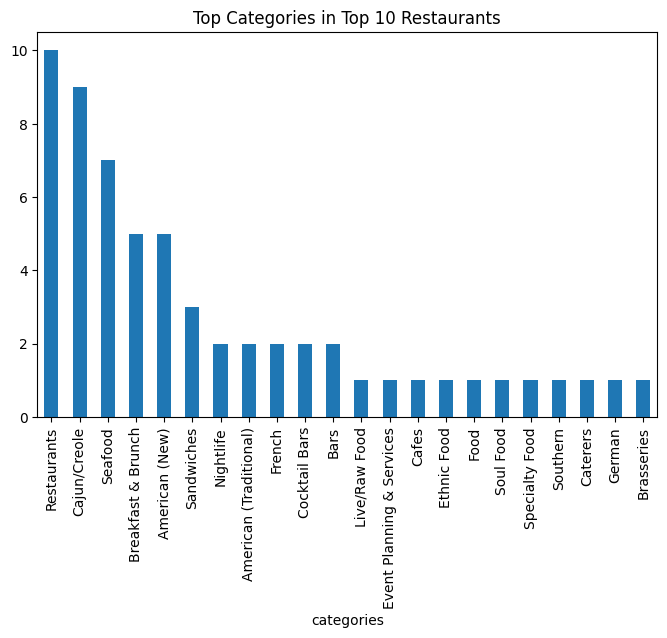

In [22]:
#We want the top 10
top10 = nolaRestaurants.sort_values(by='review_count', ascending=False).head(10)
category_counts = top10['categories'].str.split(', ').explode().value_counts()
category_counts.plot(kind='bar', figsize=(8,5), title="Top Categories in Top 10 Restaurants")

Restaurants is a category for all of these so that is why it's the tallest bar, but the second tallest bar is Cajun/Creole. This observation may indicate that Caujun/Creole restaurants are popular in this region.

#Conlusion
To answer the question from our description, we can see that based on the dataset we can observe that customer engagement, measured by the number of reviews, has a low but positive correlation with restaurant ratings. This suggests that while highly reviewed restaurants tend to have slightly higher ratings, the relationship is not very strong. Additionally, inspection of the top 10 restaurants by review count shows that many belong to the Cajun/Creole cuisine category. This indicates that cuisine type may be related to restaurant popularity in New Orleans. Overall, these findings suggest that both restaurant characteristics, such as cuisine type, and customer engagement (review counts), can influence restaurant success as measured by Yelp ratings, although other factors likely also play a role.

#Mounting Google Drive to save as html

In [24]:

from google.colab import drive
drive.mount('/content/drive')
!jupyter nbconvert --to html /content/drive/MyDrive/ColabNotebooks/Project/RestaurantProject.ipynb


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/MyDrive/ColabNotebooks/Project/RestaurantProject.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 432147 bytes to /content/drive/MyDrive/ColabNotebooks/Project/RestaurantProject.html
